# 134: Tensor-based Analysis of Cell-Cycle Drug Perturbations


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import phate

from cc_tensor import CCTensor
from cc_tensor_viz import CCTensorViz


/Users/kaiwycik/.pyenv/versions/3.13.3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CELL_LINE = "134"

features = [
    'nuclear_mean_Ki67', 'nuclear_area', 'nuclear_mean_p16', 
    'nuclear_mean_CDH1', 'nuclear_mean_cycA2', 'nuclear_mean_cycE1',
    'nuclear_mean_CDK2', 'nuclear_mean_RB', 'nuclear_mean_CycB1',
    'nuclear_mean_p21', 'nuclear_mean_cycD1', 'nuclear_mean_CDK6',
    'nuclear_mean_CDK4', 'nuclear_mean_cycA1', 'nuclear_mean_PCNA', 
    'nuclear_mean_p53', 'nuclear_mean_p27', 'nuclear_mean_cycB2', 
    'nuclear_mean_SKP2', 'nuclear_mean_CDT1', 'nuclear_mean_cycE2',
    'DNA_int'
]


## 1. Data import and preprocessing:

### 1.1 Data import:

In [3]:
adata = sc.read_h5ad(f"data/breast_cancer_zikry_wayne/{CELL_LINE}_merged.h5ad")


Removing any protein containing $``\texttt{pRB}''$ and $``\texttt{cyto}''$:

In [4]:
filter = [f for f in adata.var_names if ("pRB" not in f) and ("cyto" not in f)]
adata = adata[:, filter]

### 1.2 Preprocessing:

We exclude phases G0 and M from our data set:

In [5]:
condition_G0_M = (~adata.obs['GMM_phase_labels'].isin(['G0', 'M']))
adata = adata[condition_G0_M]

We subset to the following proteins:

In [6]:
adata = adata[:, features]

In [7]:
treatments = list(adata.obs["drug_name"].cat.categories)
phases = list(adata.obs["GMM_phase_labels"].cat.categories)
proteins = [f.replace("nuclear_mean_", "") for f in adata.var_names]

### 1.3 Data overview via PHATE:

Before any tensor work, we embed a subsample of the raw single-cell data into two dimensions using PHATE, which preserves local and global manifold structure. This provides a quick sanity check: do treatments and cell-cycle phases separate in protein space, and which proteins dominate expression?

In [8]:
adata_sub = sc.pp.subsample(adata, n_obs=min(10000, adata.n_obs), copy=True, random_state=0)
data_phate = phate.PHATE().fit_transform(adata_sub.X)

phate_df = pd.DataFrame(data_phate, columns=["PHATE 1", "PHATE 2"], index=adata_sub.obs_names)
phate_df["treatment"] = adata_sub.obs["drug_name"].astype(str).values
phate_df["phase"] = adata_sub.obs["GMM_phase_labels"].astype(str).values
phate_df["dominant_protein"] = adata_sub.to_df().idxmax(axis=1).str.removeprefix("nuclear_mean_").values

Calculating PHATE...
  Running PHATE on 10000 observations and 22 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.12 seconds.
    Calculating affinities...
    Calculated affinities in 0.50 seconds.
  Calculated graph and diffusion operator in 0.63 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.21 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.36 seconds.
  Calculated landmark operator in 1.57 seconds.
  Calculating optimal t...
    Automatically selected t = 26
  Calculated optimal t in 1.04 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.26 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.14 seconds.
Calculated PHATE in 4.95 seconds.


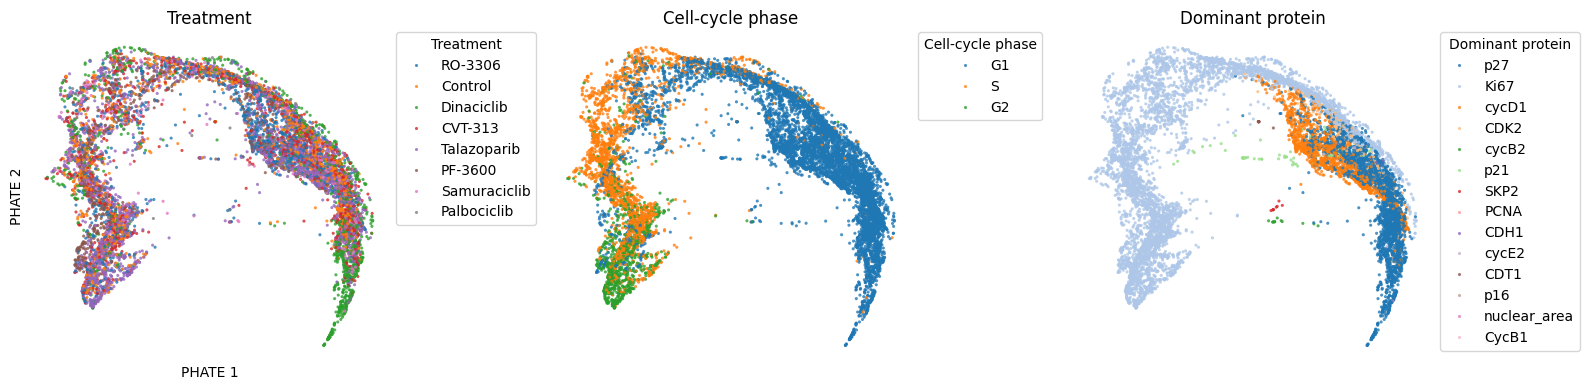

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.despine(top=True, right=True, left=True, bottom=True)
dot_size = 5

configs = [
    ("treatment", "Treatment", {}),
    ("phase", "Cell-cycle phase", {}),
    ("dominant_protein", "Dominant protein", {"palette": "tab20"}),
]

for ax, (col, title, kw) in zip(axes, configs):
    sns.scatterplot(
        data=phate_df, x="PHATE 1", y="PHATE 2", hue=col,
        s=dot_size, linewidth=0, alpha=0.8, ax=ax, **kw,
    )
    ax.set_title(title)
    ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].set_xlabel("PHATE 1")
axes[0].set_ylabel("PHATE 2")
for ax in axes[1:]:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

PHATE embeds each cell into two dimensions that preserve the manifold structure of the raw protein measurements, so nearby points have similar protein profiles. Treatment shows how strongly each drug separates cells in protein space; cell-cycle phase reveals the G1 $\to$ S $\to$ G2 progression; dominant protein labels each cell by its highest-intensity marker.

---

## 2. Tensor decomposition:

We model our data as a three-way tensor $\mathcal{X} \in \mathbb{R}^{t \times c \times p}$, where $t$ treatments, $c$ cell-cycle phases, and $p$ proteins. Each entry $\mathcal{X}_{ijk}$ is the z-scored pseudobulk mean of protein $k$ in phase $j$ under treatment $i$.

We decompose $\mathcal{X}$ via a Tucker decomposition (computed by HOSVD):

$$
\mathcal{X} \approx \mathcal{G} \times_1 T \times_2 C \times_3 P
$$

where $T \in \mathbb{R}^{t \times t_F}$, $C \in \mathbb{R}^{c \times c_F}$, $P \in \mathbb{R}^{p \times p_F}$ are orthonormal factor matrices (obtained from the SVD of each mode's unfolding), and $\mathcal{G} \in \mathbb{R}^{t_F \times c_F \times p_F}$ is the core tensor governing how factors interact across modes.

A key derived quantity is:

$$
\mathcal{F} = \mathcal{G} \times_1 T \times_2 C \in \mathbb{R}^{t \times c \times p_F}
$$

which encodes the strength of each latent protein-factor across all treatment-phase combinations in the original coordinate system. We keep the treatment and phase ranks at their maximum ($t_F = t$, $c_F = c$) and truncate only the protein rank to $p_F$.

### 2.1 Pseudobulking:

Similar to Mitchel et al. (2025), we perform pseudobulking, averaging proteins within each (treatment, cell-cycle-phase) group and z-scoring across all groups to obtain the tensor $\mathcal{X}$.

In [10]:
cct = CCTensor(adata, treatments=treatments, cc_phases=phases, proteins=proteins)
cct.pseudobulk()
print(f"Pseudobulk tensor shape: {cct.tensor.shape}")

Pseudobulk tensor shape: (8, 3, 22)


### 2.2 Protein rank selection:

To choose $p_F$, we sweep protein ranks from 1 to $p$ (keeping $t_F = t$ and $c_F = c$ fixed), reconstruct the tensor at each rank, and compute the relative Frobenius error $\|\hat{\mathcal{X}} - \mathcal{X}\|_F / \|\mathcal{X}\|_F$. The optimal rank is identified by the maximum gap between the error curve and a linear interpolation from rank 1 to rank $p$ (an elbow heuristic).

Maximum difference at step 10: 0.33692922564923106


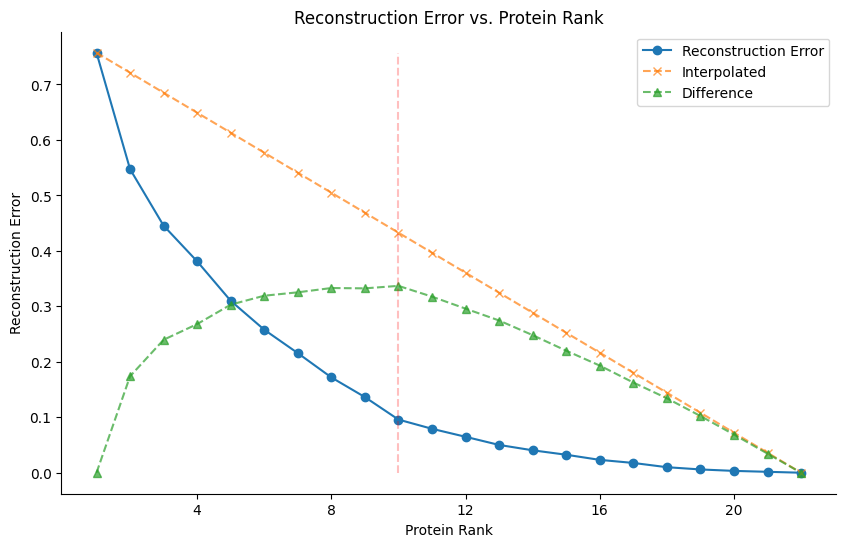

10

In [11]:
cct.determine_rank()

After considering our results, we proceed with 4 latent protein-factors.

In [12]:
n_protein_factors = 4
truncation_rank = [len(treatments), len(phases), n_protein_factors]
cct.set_tensor_decompositions(truncation_rank=truncation_rank)


In [13]:
viz = CCTensorViz(cct)

---

## 3. Tensor diagnostics:

Singular value spectrum:

For each mode $k \in \{1, 2, 3\}$, we unfold $\mathcal{X}$ into a matrix $\mathbf{X}_{(k)}$ and compute its singular values $\sigma_1 \geq \sigma_2 \geq \dots$. These are the same singular values that the HOSVD uses to construct the factor matrices. The cumulative explained variance $\sum_{i=1}^{r} \sigma_i^2 \big/ \sum_i \sigma_i^2$ shows how many components are needed to capture most of the variation along each mode.

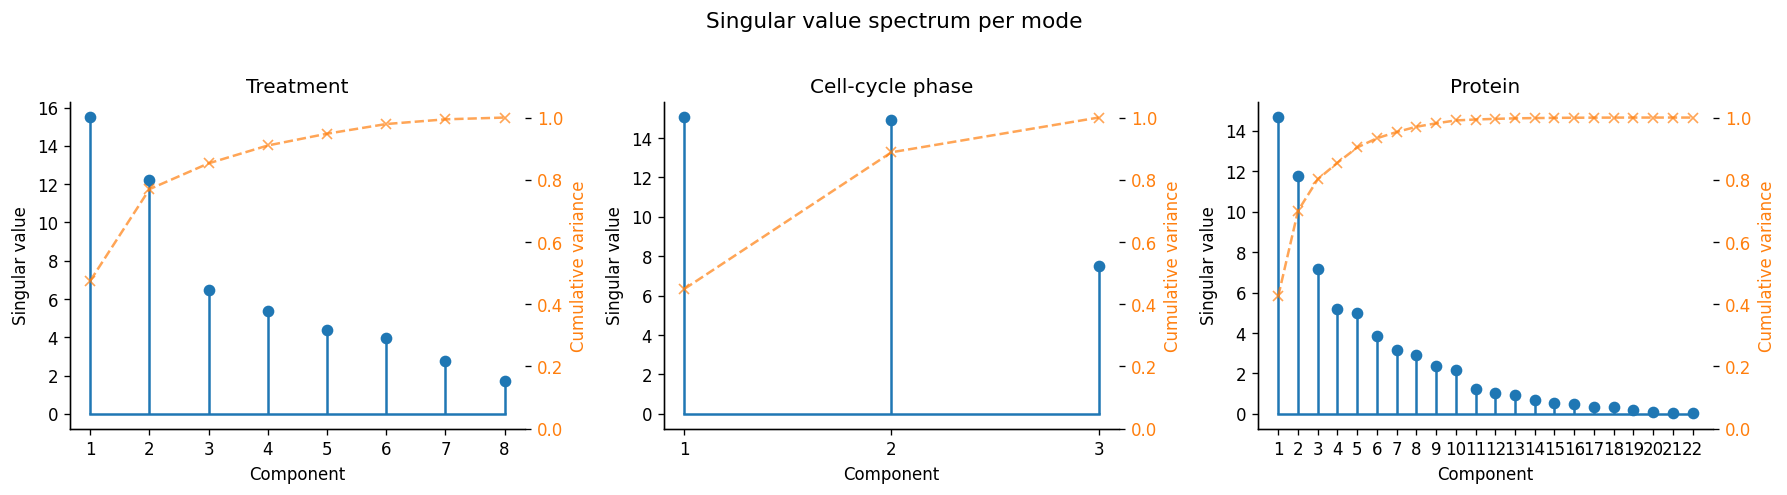

In [14]:
viz.singular_value_spectrum();

The treatment and phase modes have as many components as they have categories, and are kept at full rank. The protein mode has 22 components, but most of the variance is concentrated in the first few, justifying truncation to $p_F = 4$.

---

## 4. Latent factors:

### 4.1 Protein loadings:

The protein factor matrix $P \in \mathbb{R}^{p \times p_F}$ has one column per latent protein-factor. Entry $P_{kf}$ gives the weight of protein $k$ on factor $f$. Because the columns are orthonormal, each factor defines a direction in protein space; proteins with the same sign co-vary along that direction, and opposite signs indicate anti-correlation. The overall sign of a column is arbitrary (flipping a factor and its corresponding core slice leaves the reconstruction unchanged).

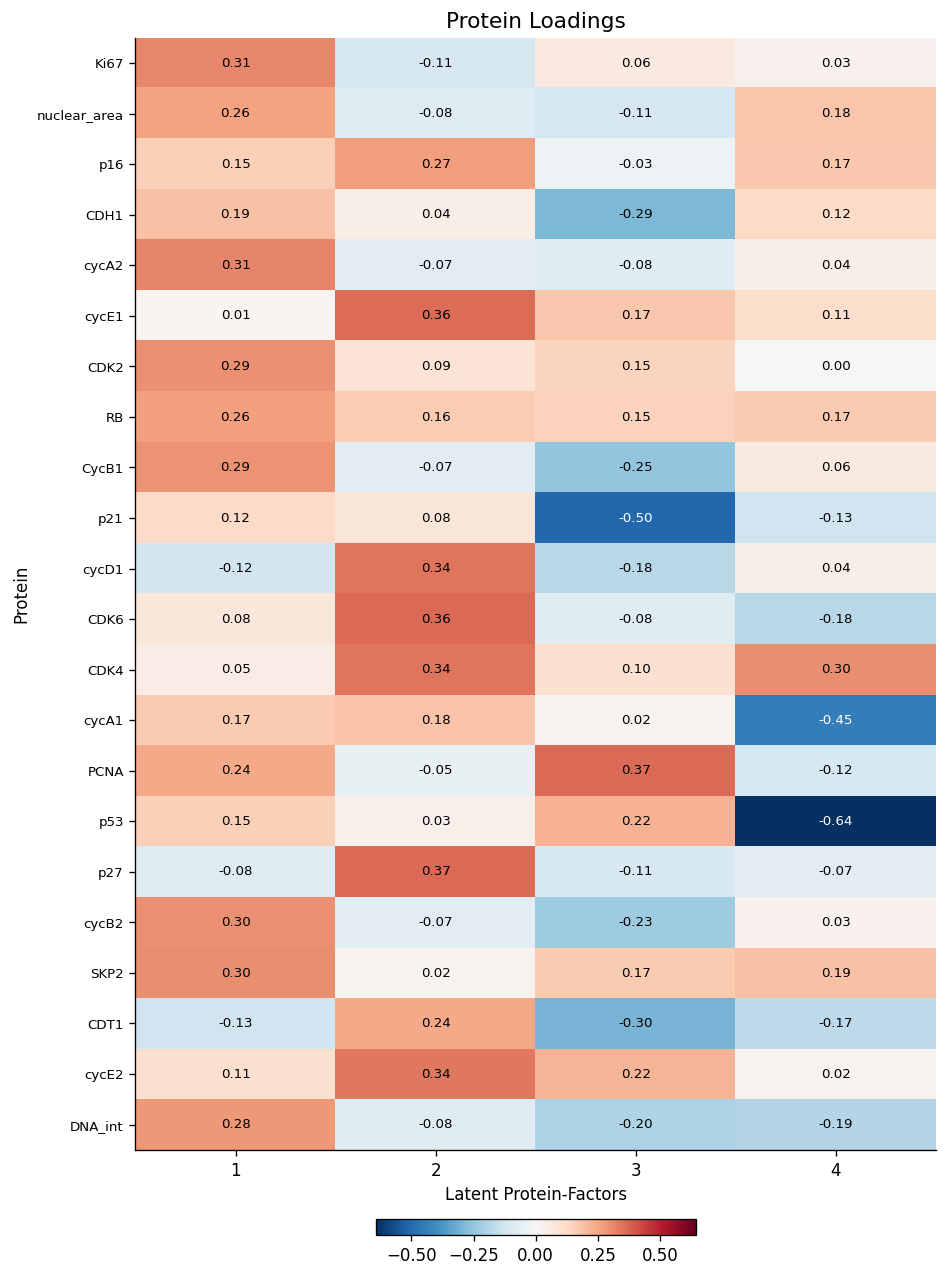

In [15]:
viz.protein_loadings_heatmap();

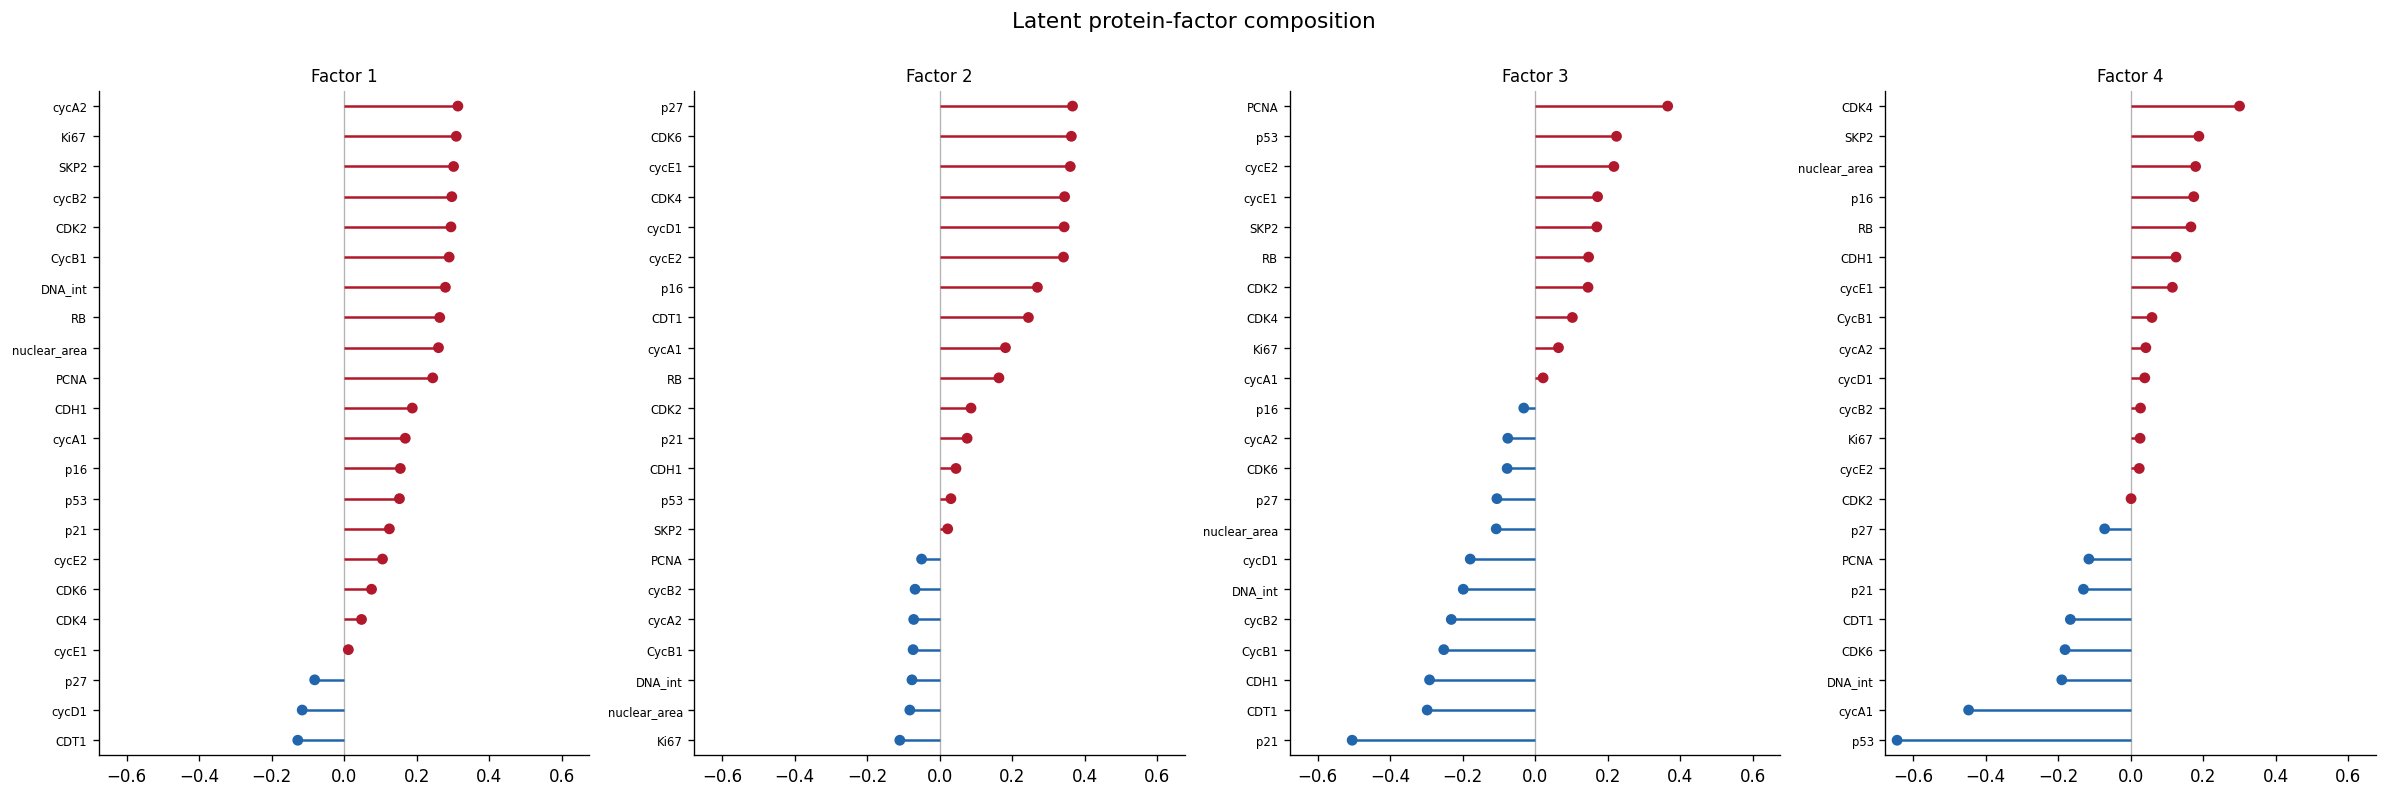

In [16]:
viz.protein_loadings_lollipop();

The lollipop charts show the same loading values sorted by magnitude within each factor. This makes it easy to identify the dominant contributors (the proteins at the extremes) and the direction of their contribution.

### 4.2 Treatment loadings:

The treatment factor matrix $T \in \mathbb{R}^{t \times t_F}$ captures how each treatment loads onto the latent treatment-factors. Because the treatment mode is kept at full rank ($t_F = t$), this matrix is a square orthonormal basis; its entries show the coordinates of each treatment in the rotated factor space.

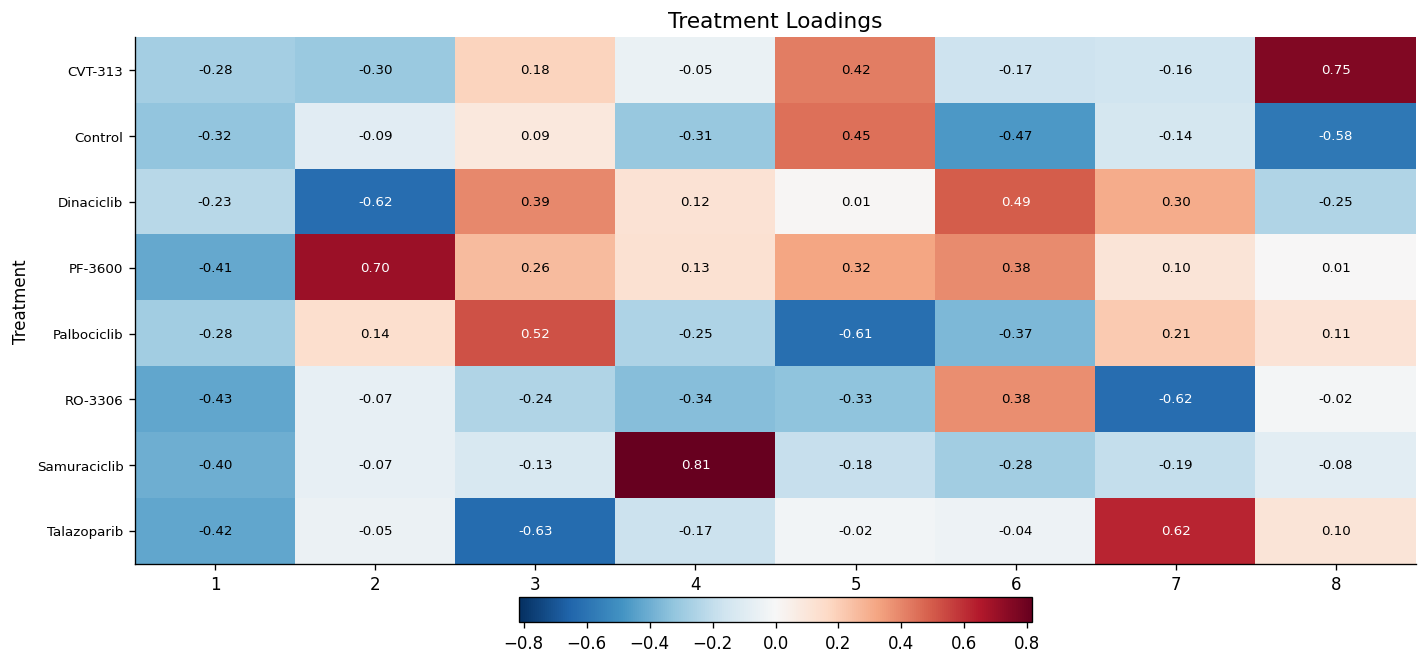

In [17]:
viz.treatment_loadings_heatmap();

### 4.3 Latent factor clustering:

To understand which proteins behave similarly in latent factor space, we compute the cosine similarity between all pairs from their respective factor matrices. For proteins, the Gram matrix $\hat{P}\hat{P}^\top$ (where $\hat{P}$ is row-normalized) gives the pairwise cosine similarity. We use Agglomerative clustering with average linkage on the derived distance $(1 - \text{similarity})/2$ to reveal groups of proteins with similar latent factor profiles.

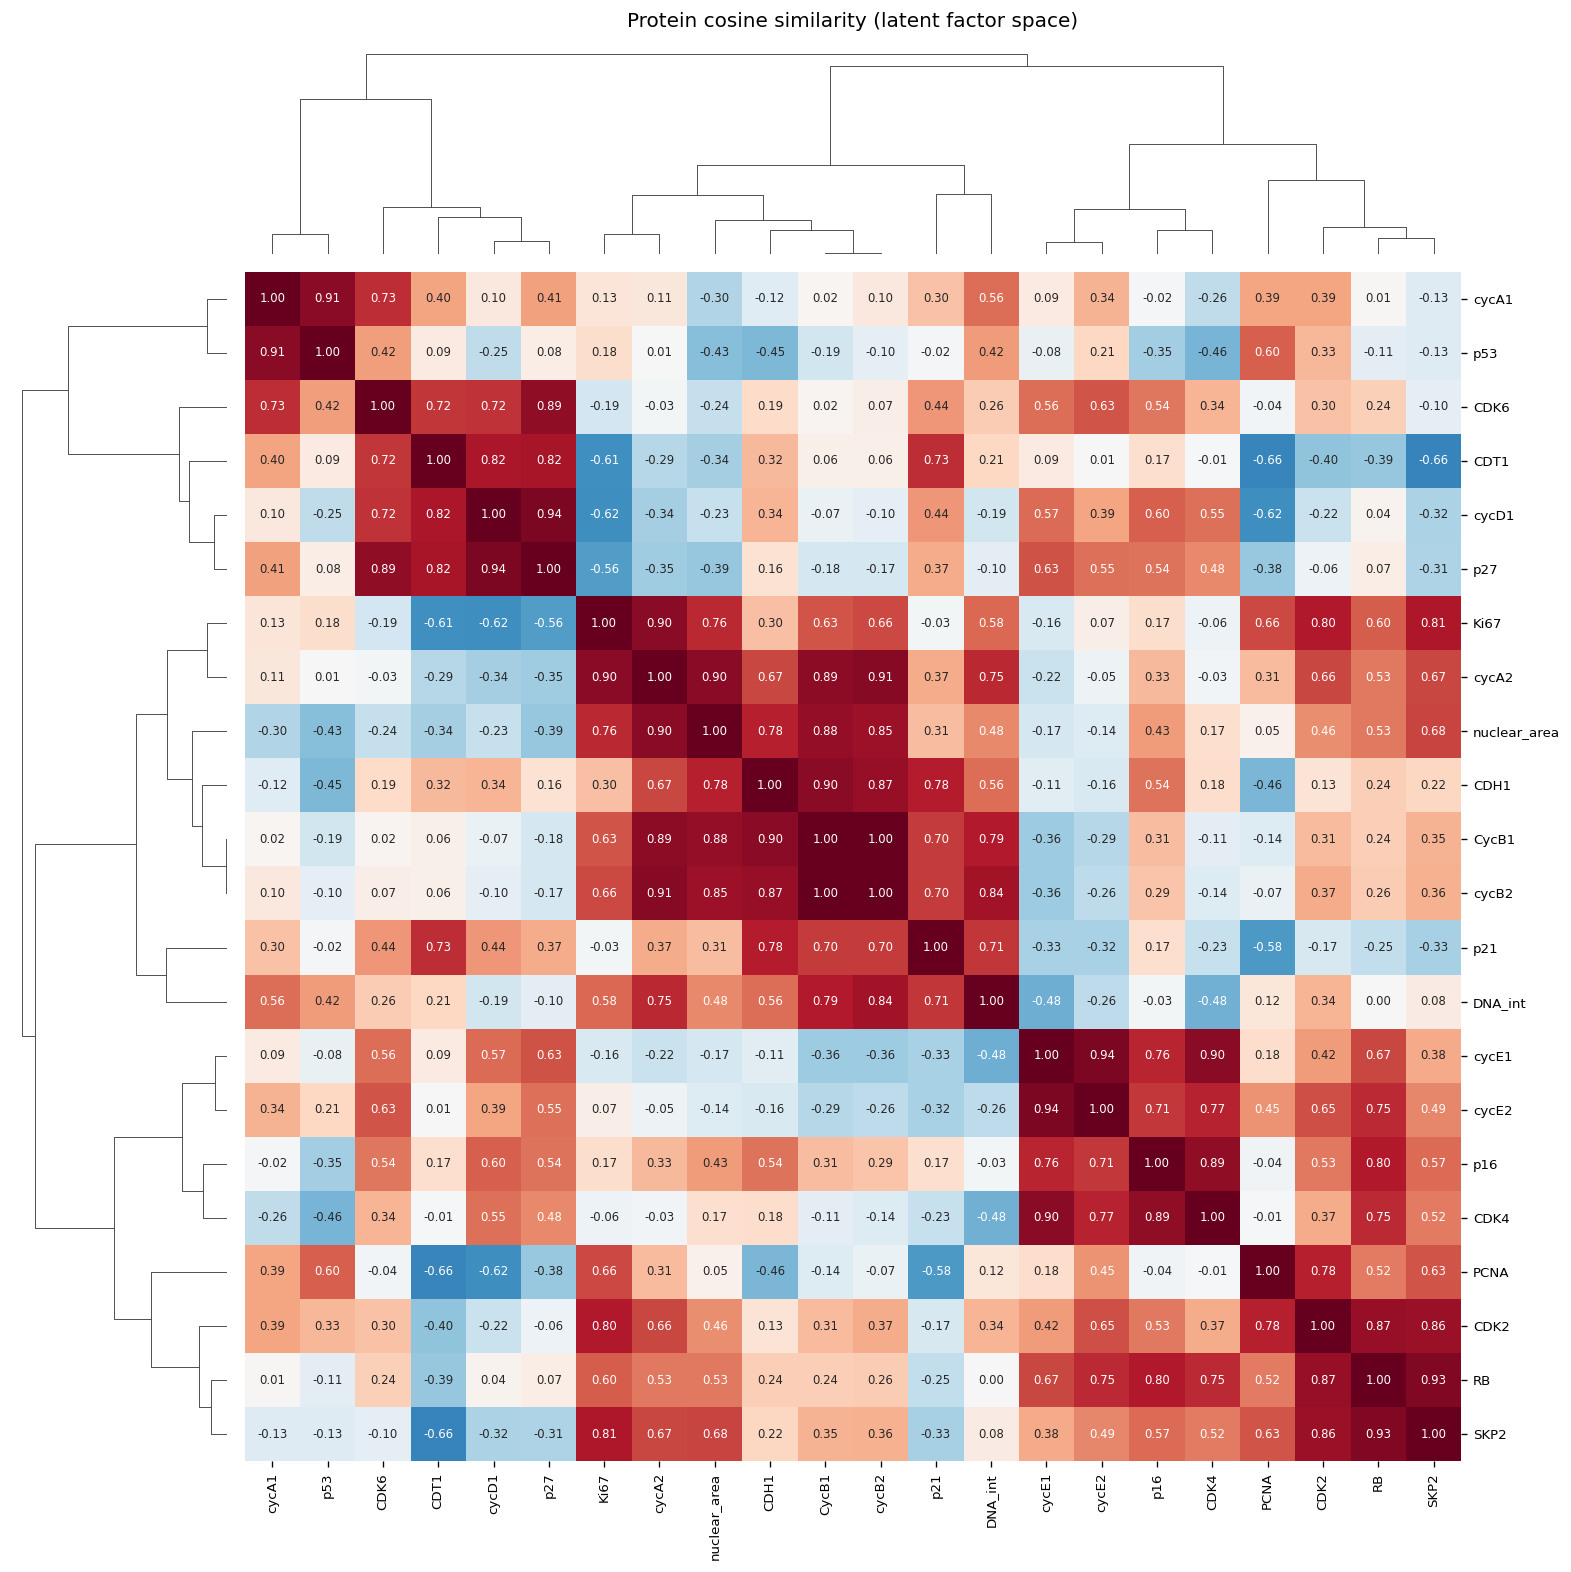

In [18]:
viz.gram_clustermap(mode="protein");

### 4.4 F slice montage:

The tensor $\mathcal{F} = \mathcal{G} \times_1 T \times_2 C \in \mathbb{R}^{t \times c \times p_F}$ maps the core back into the original treatment and phase coordinates while retaining the latent protein-factor axis. Each frontal slice $\mathcal{F}_{:,:,f}$ is a $t \times c$ matrix showing how strongly factor $f$ is expressed across all treatment-phase combinations. Positive values mean the factor points in its "positive" direction (per the loading signs above); negative values mean it points in the opposite direction.

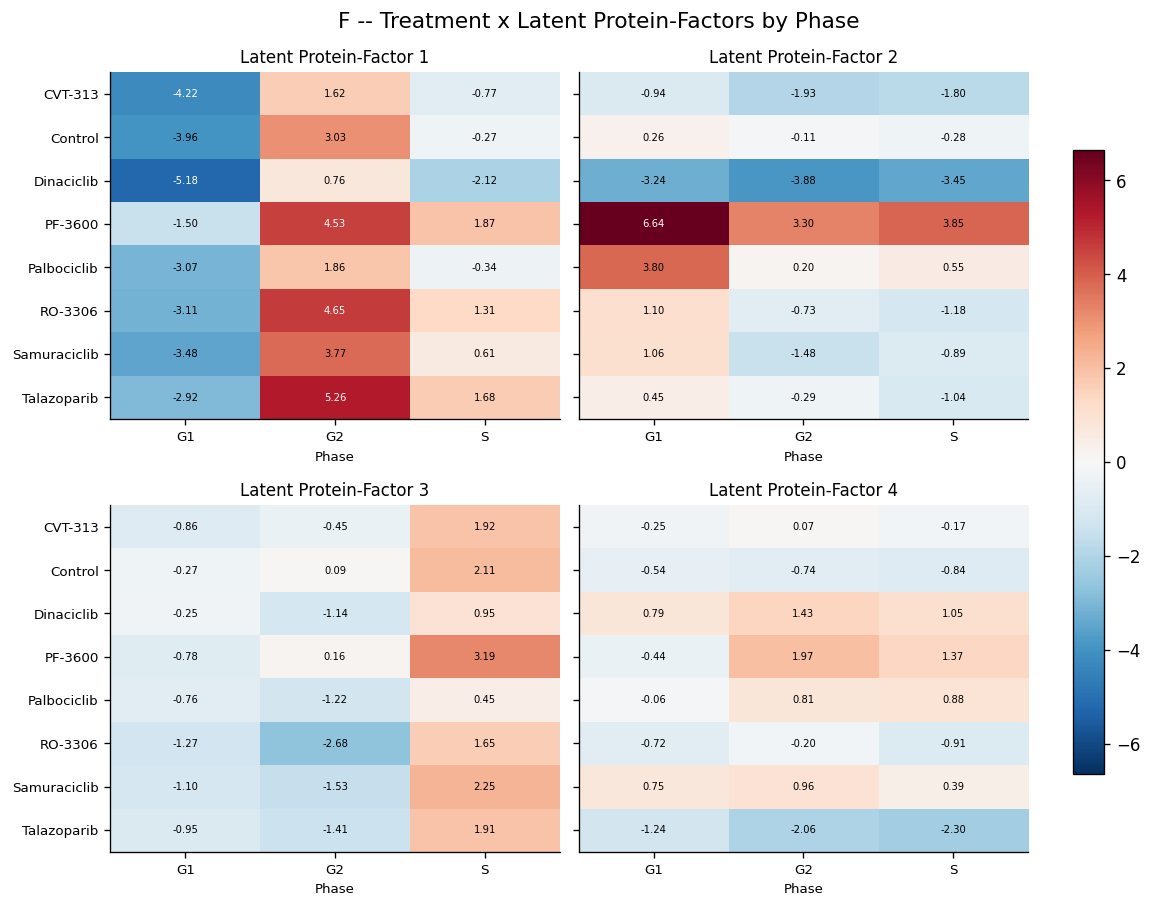

In [19]:
viz.F_slice_montage();

### 4.5 Control-normalized F slice montage:

To isolate treatment effects on the latent protein-programs across the cell cycle, we subtract the control row from F. Each entry now shows the deviation from control for that (treatment, phase, factor) combination.

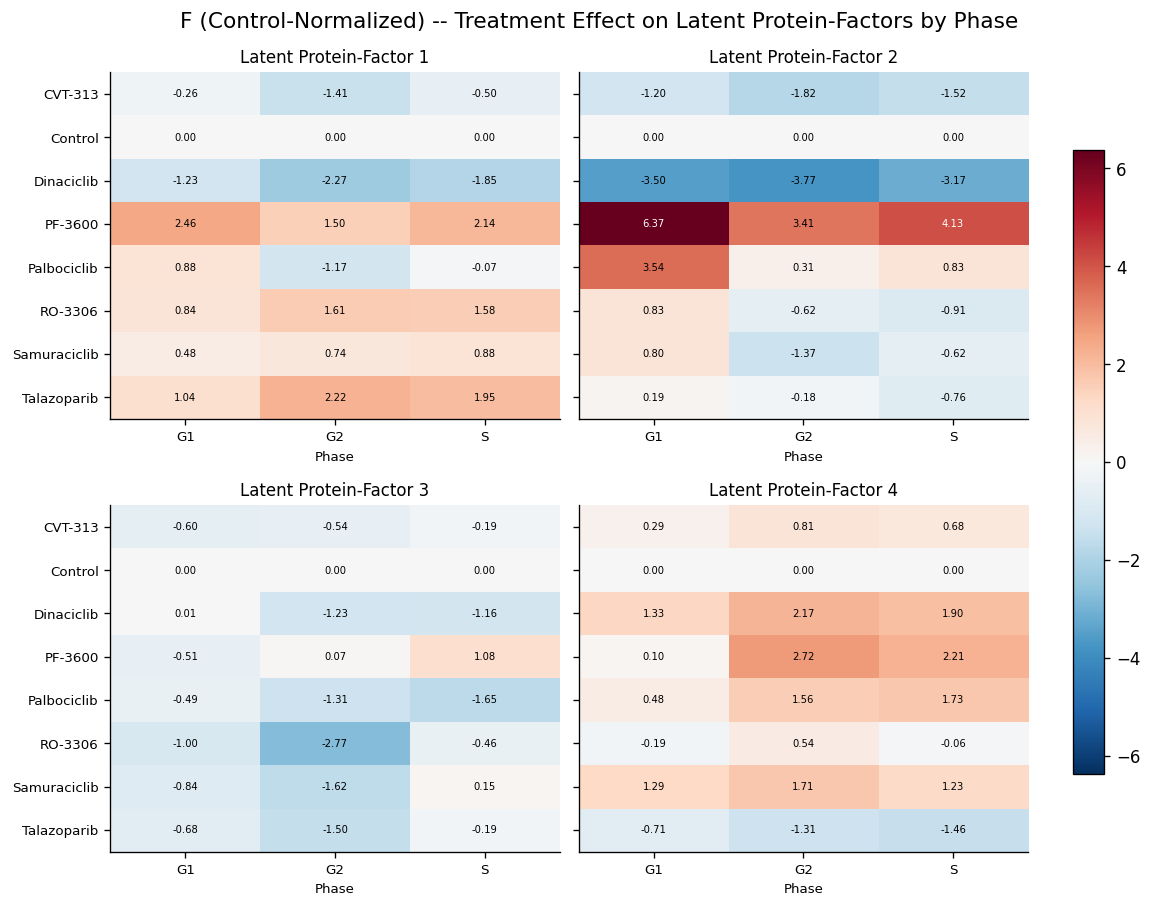

In [20]:
viz.F_slice_montage_normalized();

---

## 5. Single-cell factor projections:

The decomposition above operates on the pseudobulk tensor. To understand how the latent protein-factors manifest at the single-cell level, we project individual cells into factor space. Given a cell's protein vector $\mathbf{x} \in \mathbb{R}^p$, we z-score it using the global mean $\boldsymbol{\mu}$ and standard deviation $\boldsymbol{\sigma}$, then project:

$$
\mathbf{s} = \left(\frac{\mathbf{x} - \boldsymbol{\mu}}{\boldsymbol{\sigma}}\right) P \in \mathbb{R}^{p_F}
$$

The resulting score $s_f$ measures how strongly cell $\mathbf{x}$ expresses the protein program defined by factor $f$.

We color the global PHATE embedding by each factor's score $s_f$. This reveals the spatial organization of each protein program across the manifold.

Computing global PHATE embedding...
Calculating PHATE...
  Running PHATE on 10000 observations and 22 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.11 seconds.
    Calculating affinities...
    Calculated affinities in 0.11 seconds.
  Calculated graph and diffusion operator in 0.23 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.23 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.40 seconds.
  Calculated landmark operator in 1.63 seconds.
  Calculating optimal t...
    Automatically selected t = 27
  Calculated optimal t in 1.04 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.33 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 4.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.23 seconds.
Calculated PHATE in 4.71 seconds.


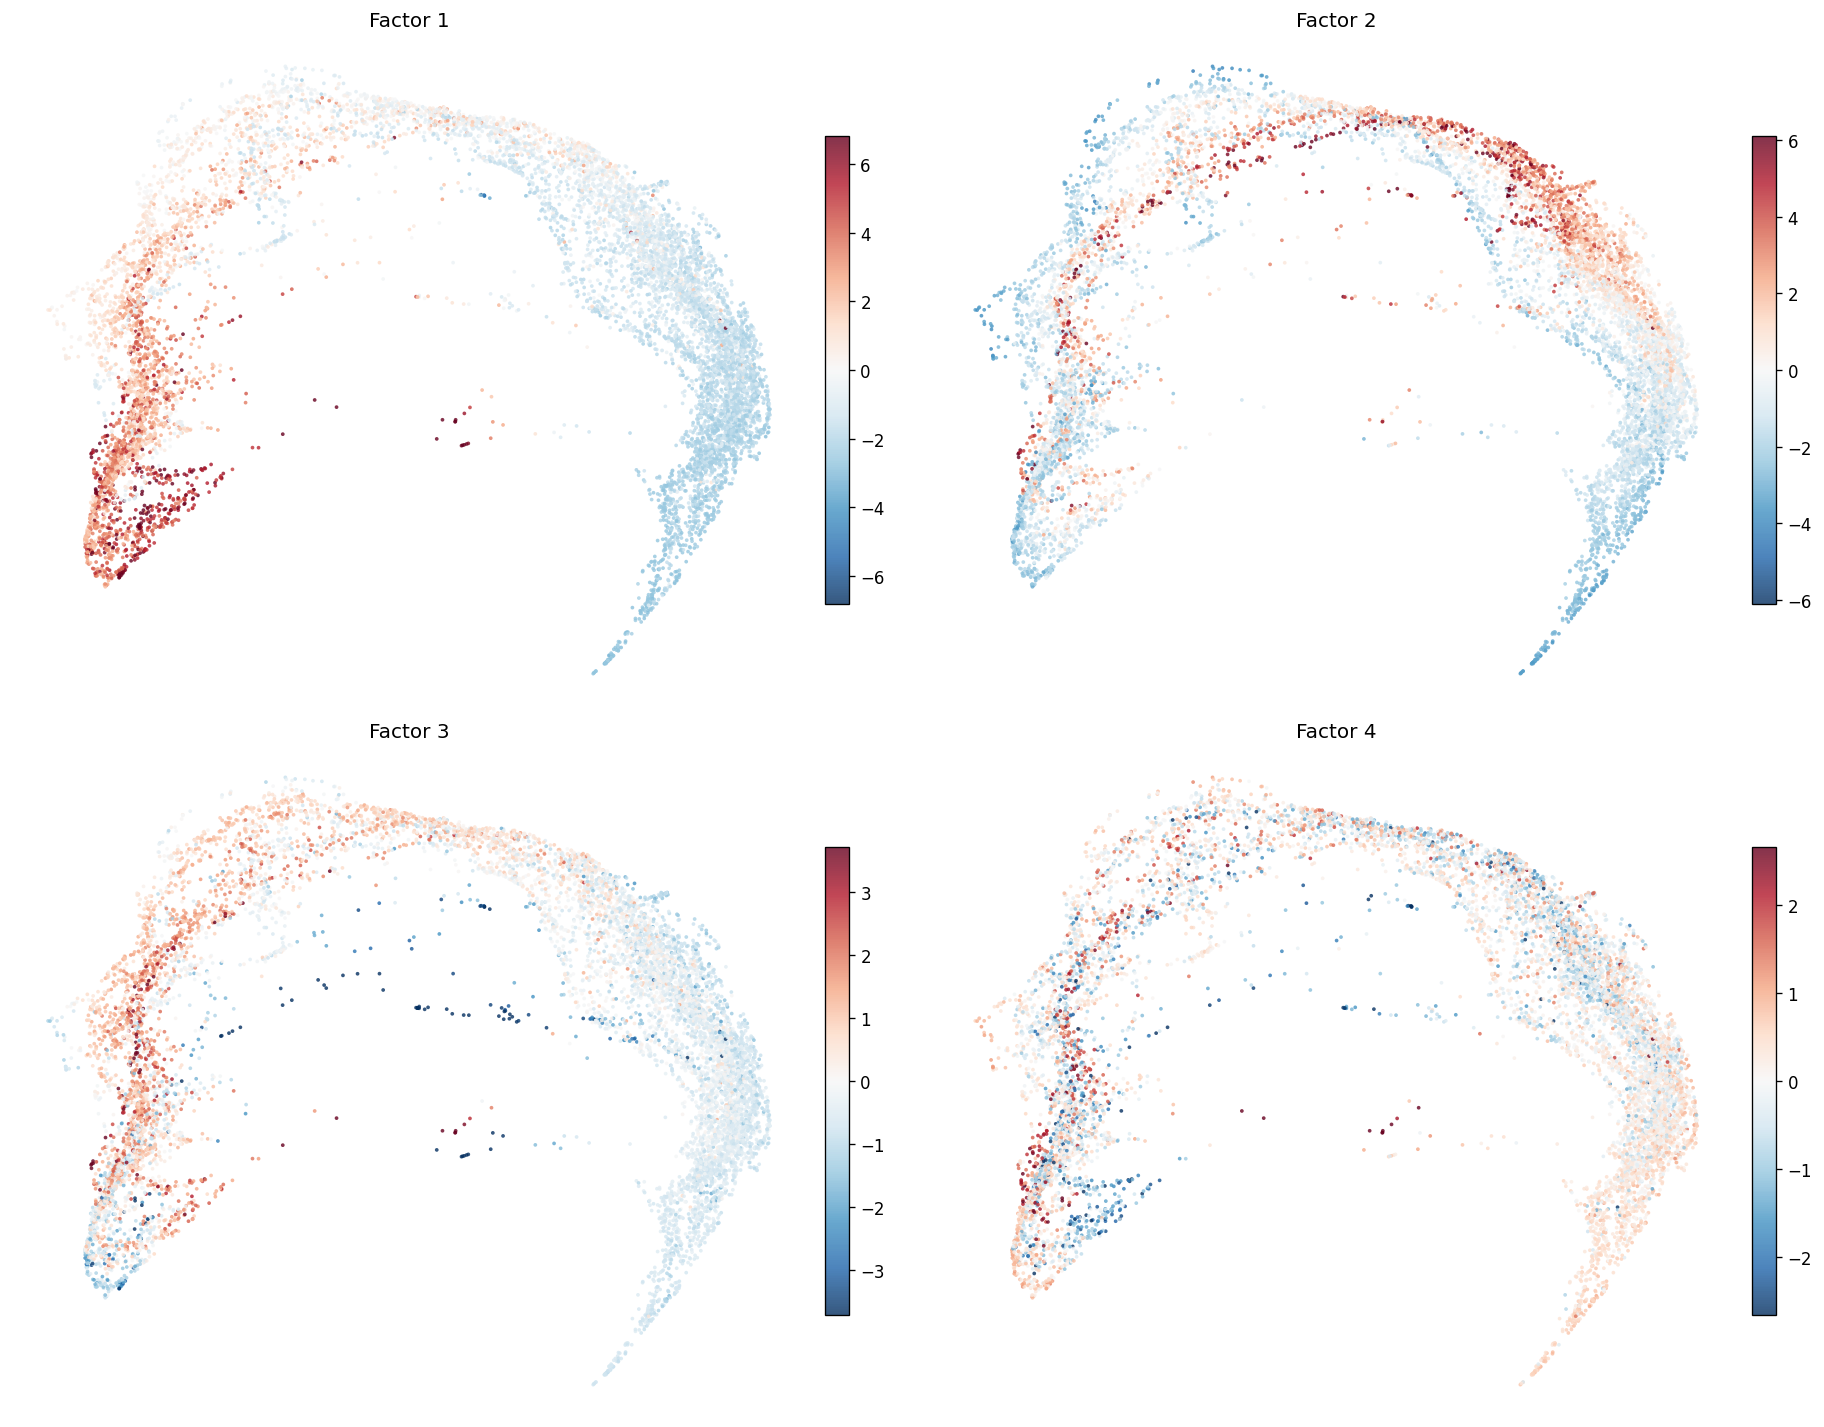

In [21]:
viz.phate_factor_scores();

---

## 6. Per-treatment analysis:

### 6.1 Factor scores by treatment:

For each cell, we project its z-scored protein vector onto the protein factor matrix to obtain factor scores $s_f = \mathbf{z}^\top \mathbf{p}_f$. The violins show these scores grouped by treatment and colored by cell-cycle phase. Positive scores indicate alignment with the factor direction; negative scores indicate opposition. This reveals which protein programs each treatment activates or suppresses.


Computing per-treatment PHATE embeddings...
    SGD-MDS may not have converged: stress changed by -3.3% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by 12.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by 2.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by 3.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -3.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.


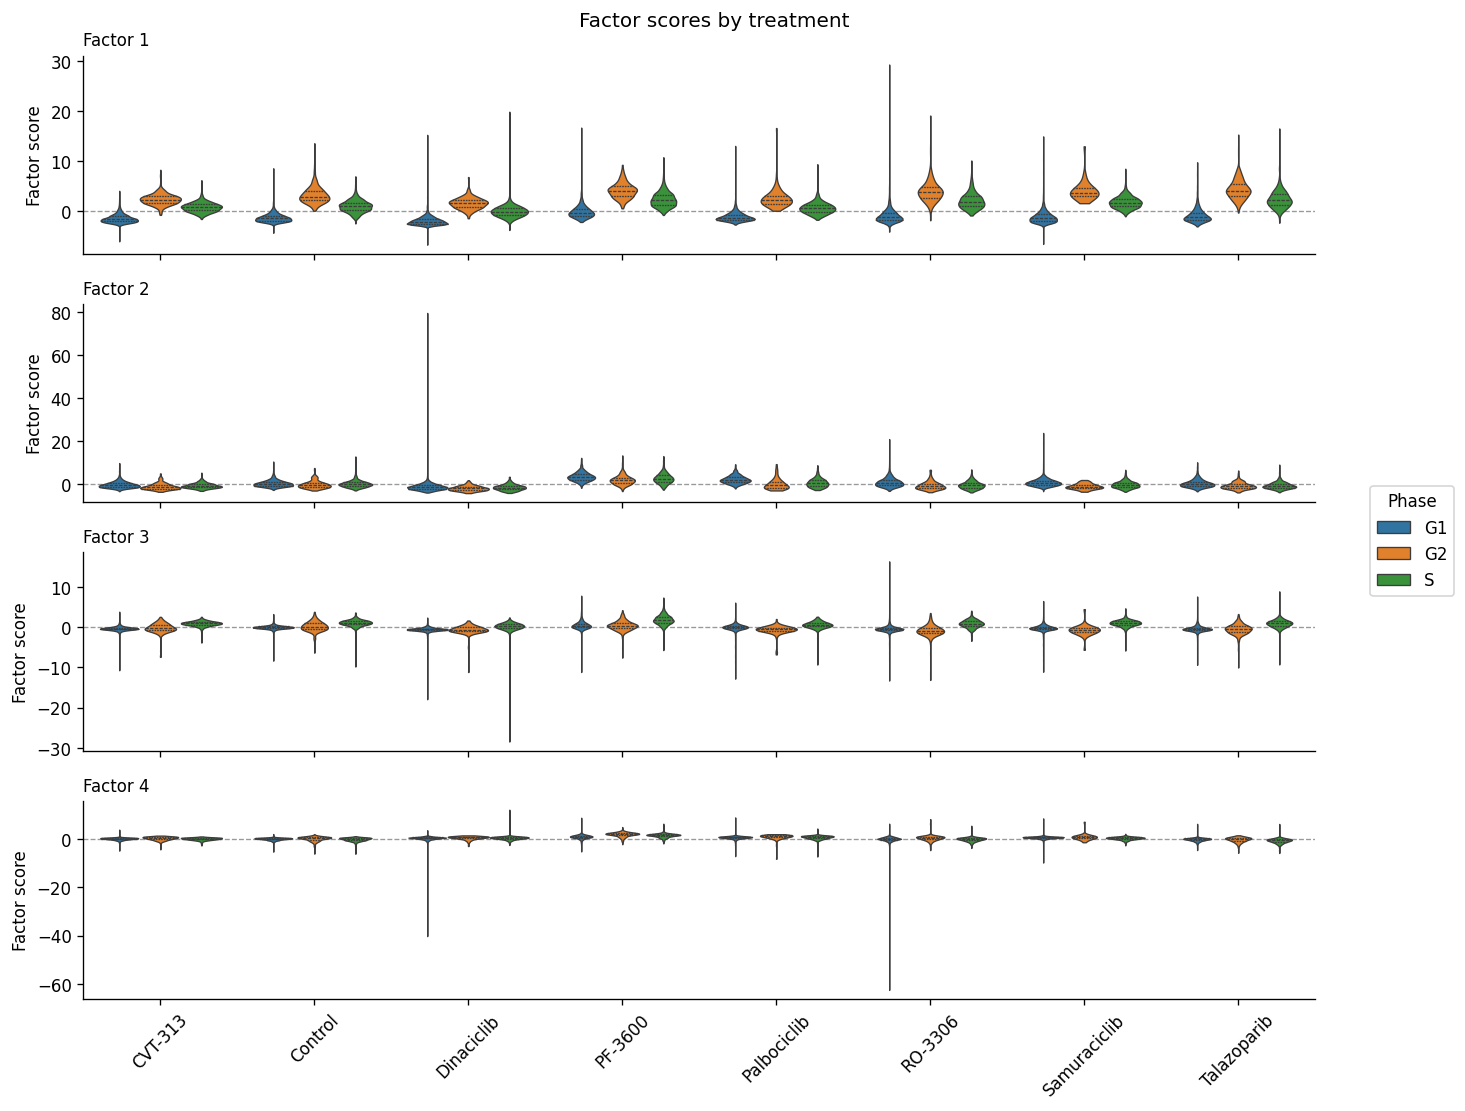

In [22]:
viz.factor_score_violins();

### 6.2 Cosine distance to factor archetypes:

For each cell with z-scored protein vector $\mathbf{z} = (\mathbf{x} - \boldsymbol{\mu})/\boldsymbol{\sigma}$ and factor scores $\mathbf{s} = \mathbf{z} P$, we compute the cosine distance to each factor's axis:

$$
d_f = 1 - \frac{s_f}{\|\mathbf{z}\|}
$$

Since the columns of $P$ are unit vectors, $s_f / \|\mathbf{z}\|$ equals the cosine of the angle between $\mathbf{z}$ and the $f$-th factor direction. A cosine distance near 0 means the cell's protein profile is closely aligned with that factor; a value near 1 means orthogonality; values above 1 indicate opposition. The violins show these distances stratified by treatment and colored by cell-cycle phase.

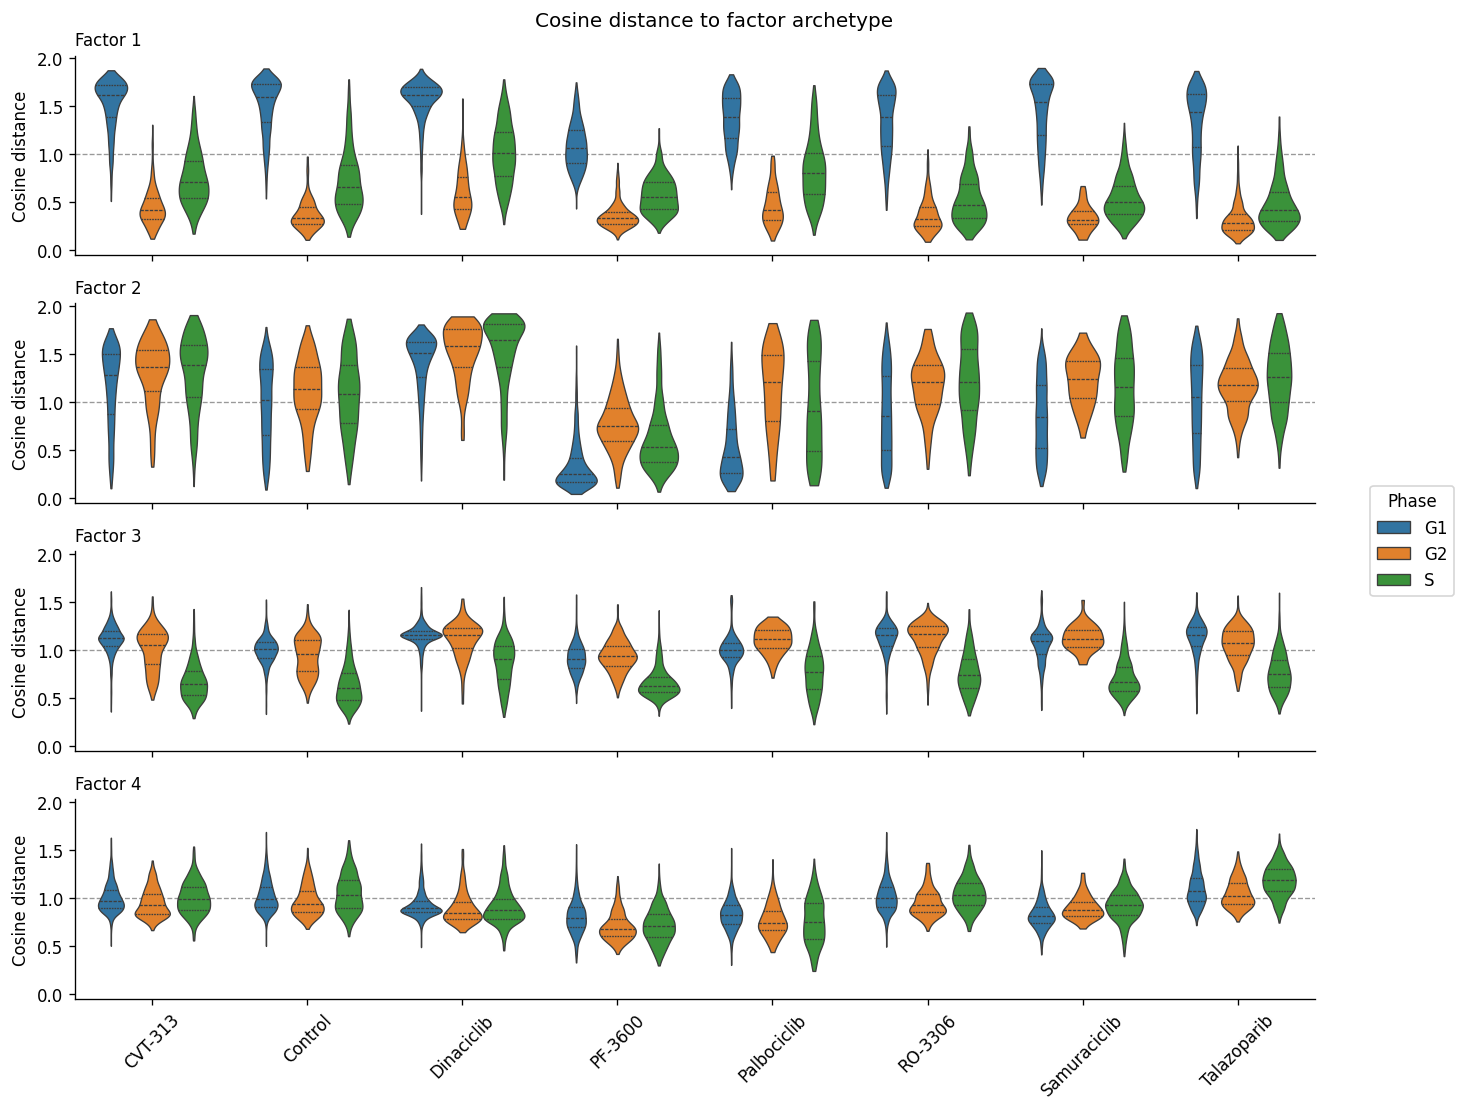

In [23]:
viz.cosine_distance_violins();

### 6.3 Per-treatment local PHATE by latent protein-factor:

To examine how factors distribute within each treatment's cell population, we compute a separate PHATE embedding for each treatment (up to 3,000 cells per treatment, z-scored and embedded independently). Each panel is colored by the corresponding factor score $s_f$. 

Contour lines indicate the boundaries of each cell-cycle phase (G1 in green, S in orange, G2 in red), estimated via kernel density.

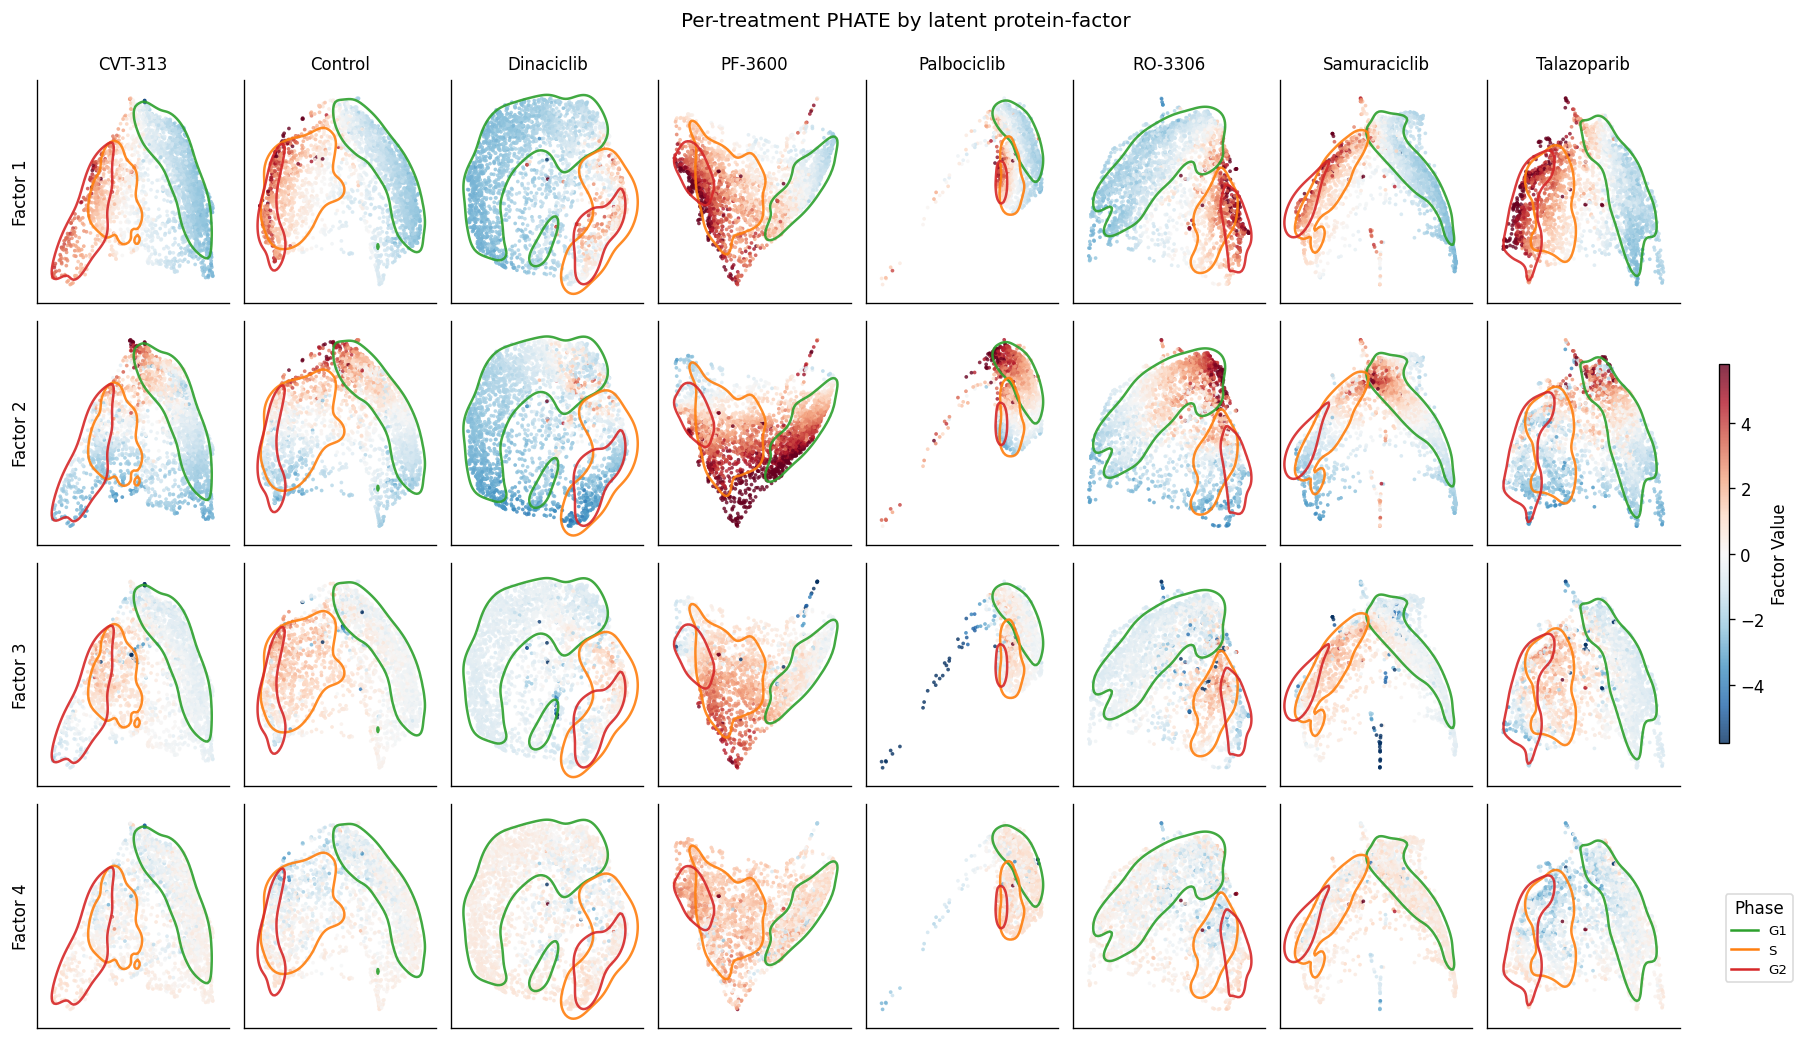

In [24]:
viz.phate_local_by_factor(show_phase_contours=True);

### 6.4 Per-treatment global PHATE by latent protein-factor:

Same layout as above, but using the shared global PHATE coordinates (masked by treatment). This sacrifices within-treatment resolution but enables direct spatial comparison across treatments: cells in the same position across panels occupy the same region of the global manifold.

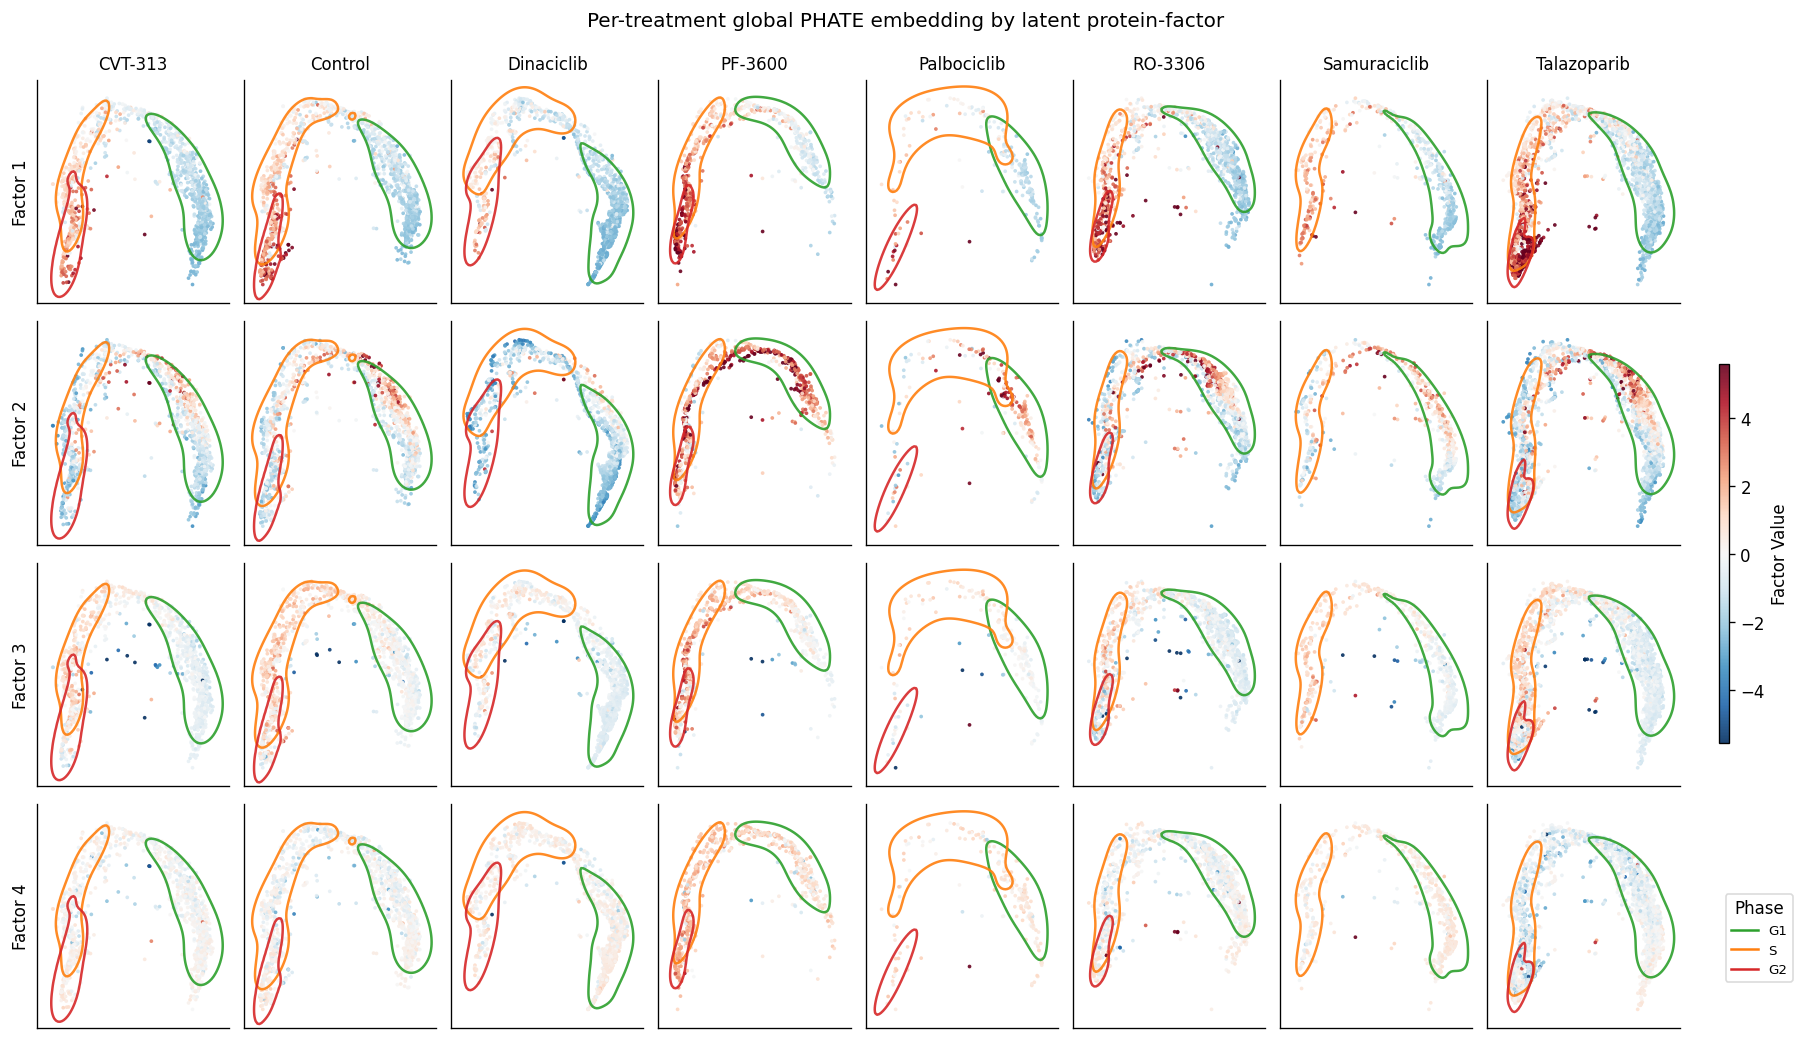

In [25]:
viz.phate_global_by_factor(show_phase_contours=True);

---

## 7. Pseudotime analysis:

The tensor decomposition and per-treatment analyses above use discrete phase labels (G1, S, G2). To obtain a continuous view of how factor scores evolve through the cell cycle, we estimate a diffusion pseudotime (DPT) independently for each treatment.

For each treatment's subsampled cells (z-scored in the raw protein space), we:

1. We build a k-nearest-neighbor graph and compute the diffusion map (which is the transition matrix of a random walk on the neighborhood graph) and get the top eigenvectors of the transition matrix on the cell graph. (via $\texttt{sc.pp.neighbors}$ and $\texttt{sc.tl.diffmap}$)
2. We then select a root cell among G1-labeled cells (the cell with the smallest first diffusion component), anchoring pseudotime at early G1.
3. Finally, we obtain DPT as the geodesic distance from the root along the diffusion map. We get a scalar $\tau \in [0, \infty)$ for each cell that increases monotonically along the dominant trajectory. (via $\texttt{sc.tl.dpt}$)

Each treatment gets one row with two panels. Left: the factor score plotted against pseudotime $\tau$, with cells colored by phase (G1, S, G2) and a LOWESS-smoothed trend in black. Right: the per-treatment PHATE embedding colored by $\tau$, showing the spatial layout of the pseudotime ordering on the manifold. Differences between rows reveal how each drug alters the temporal dynamics of the protein program.

Computing per-treatment diffusion pseudotime...


/Users/kaiwycik/GitHub/Tensors and Cell Cycles/code/cc_tensor_viz.py:831: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.90, 0.99])


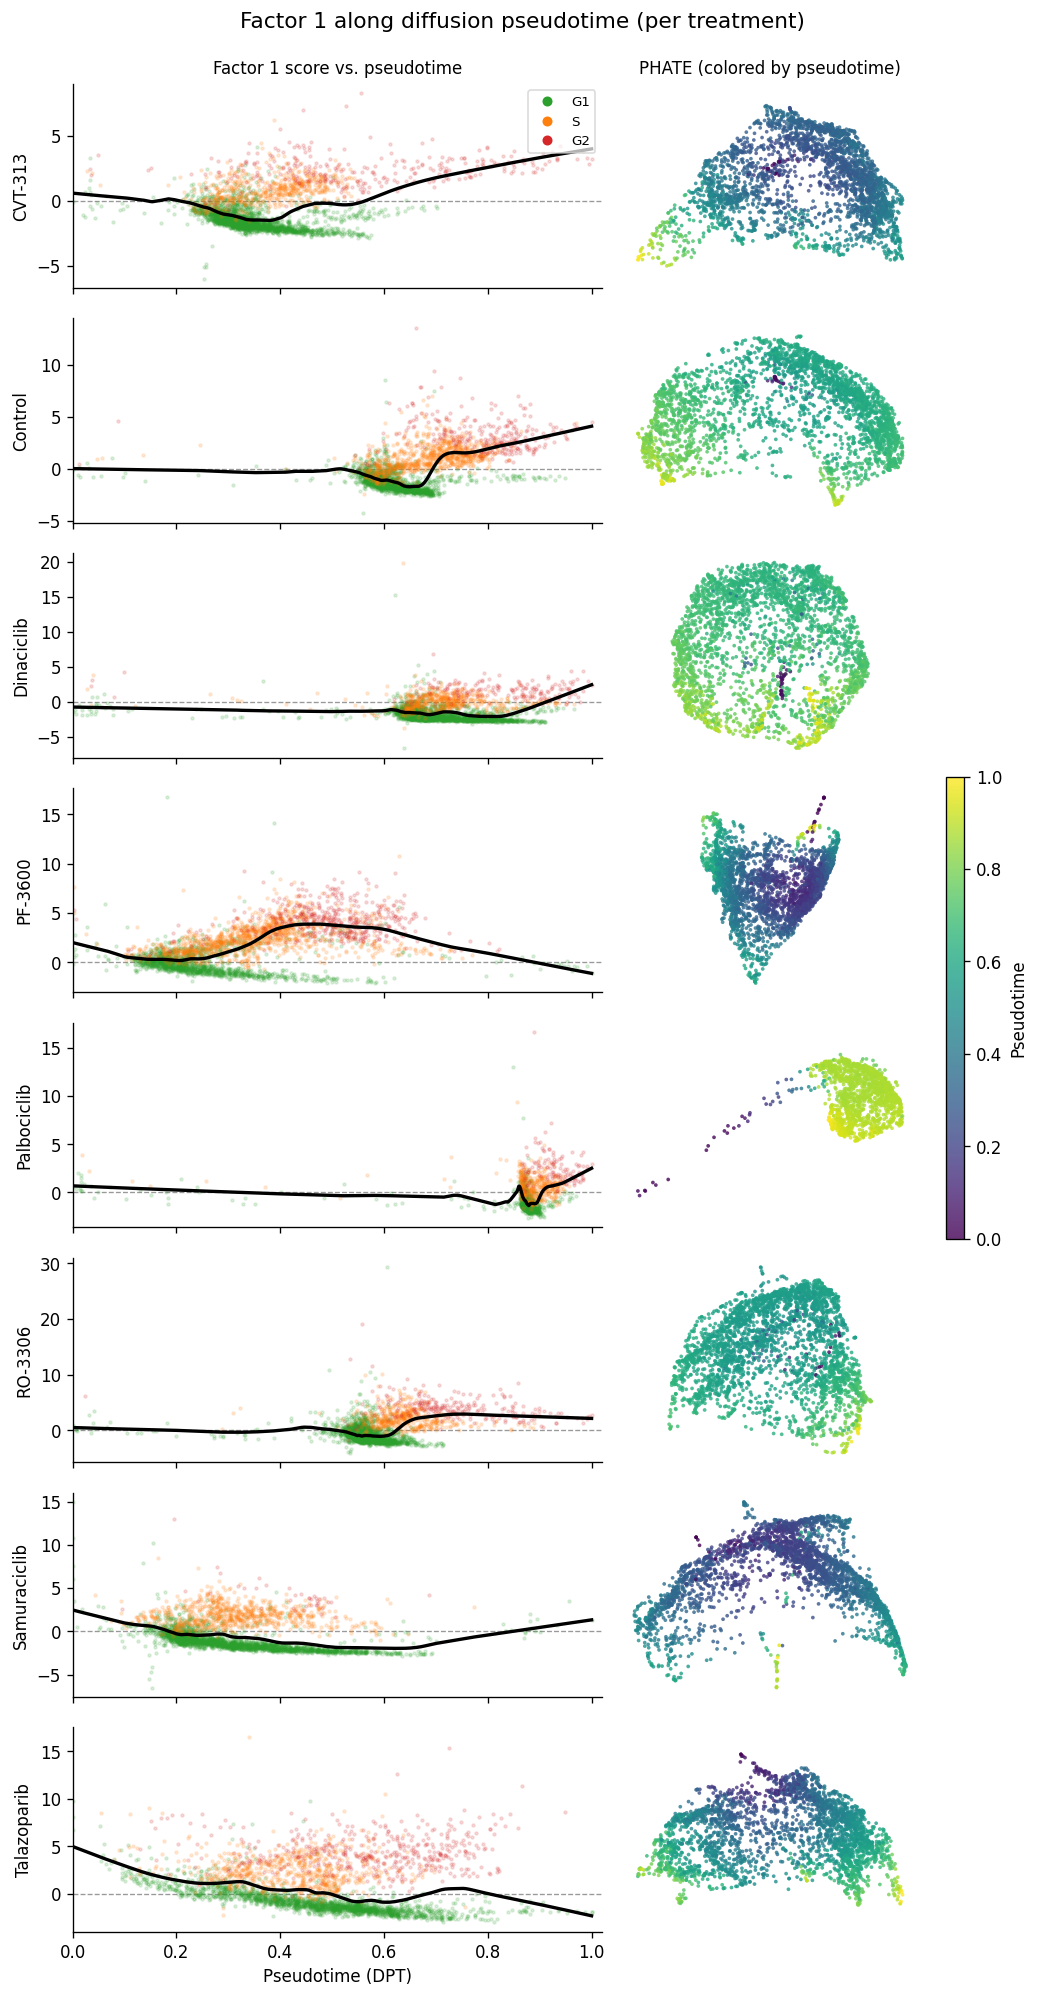

In [26]:
viz.pseudotime_factor_curves();

/Users/kaiwycik/GitHub/Tensors and Cell Cycles/code/cc_tensor_viz.py:831: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.90, 0.99])


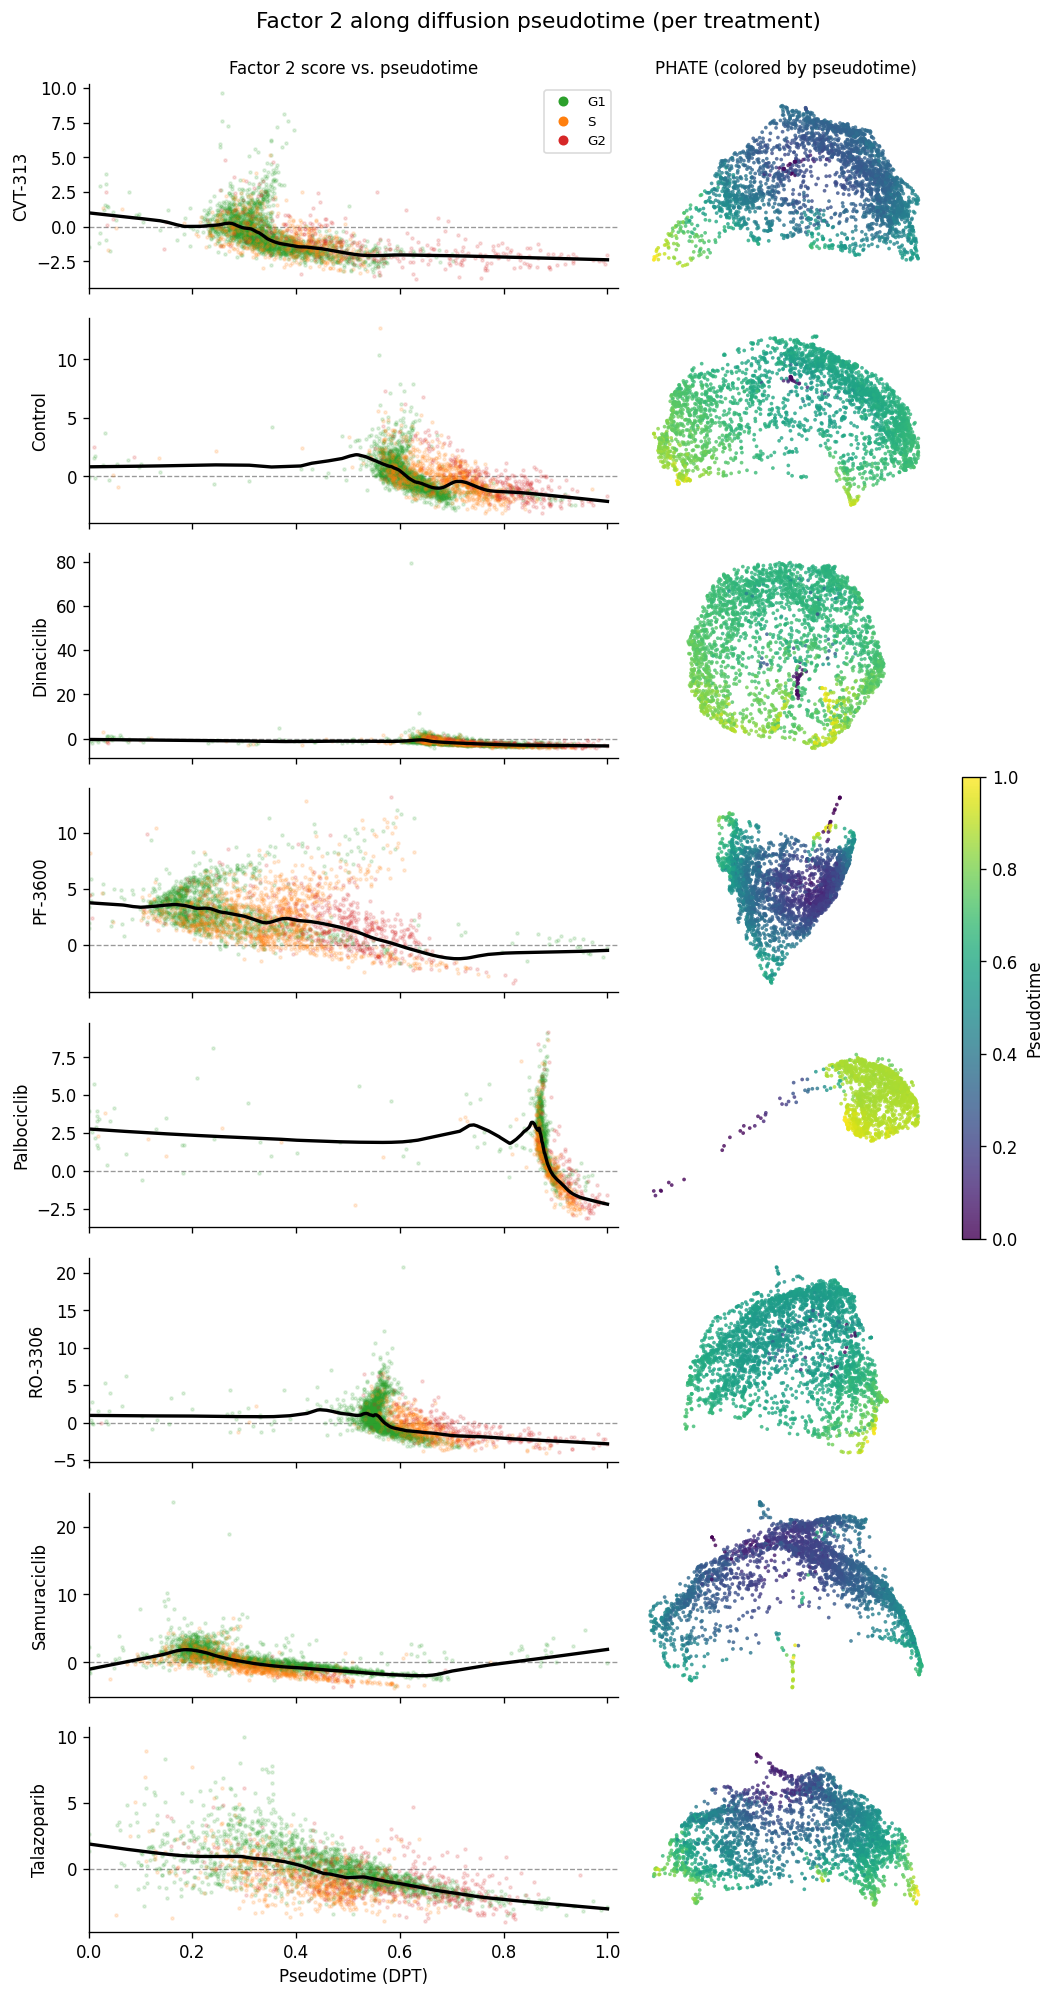

In [27]:
viz.pseudotime_factor_curves(factor=1);

---

## 8. Save results:

In [28]:
Path("results").mkdir(exist_ok=True)
with open(f"results/cct_{CELL_LINE}.pkl", "wb") as f:
    pickle.dump(cct, f)
